# Actividad 1: Regresión Lineal en Palmer Penguins
### Paso 1: Preparación y organización de datos
### Paso 2: Exploración de datos (AED)

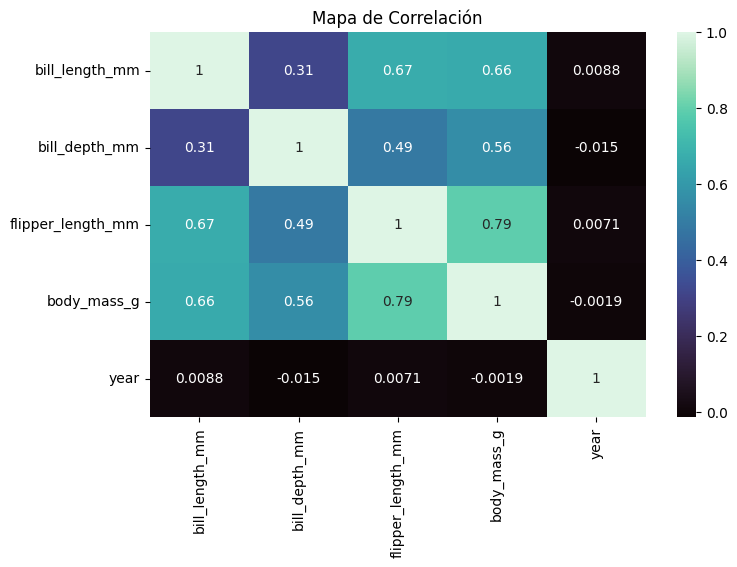

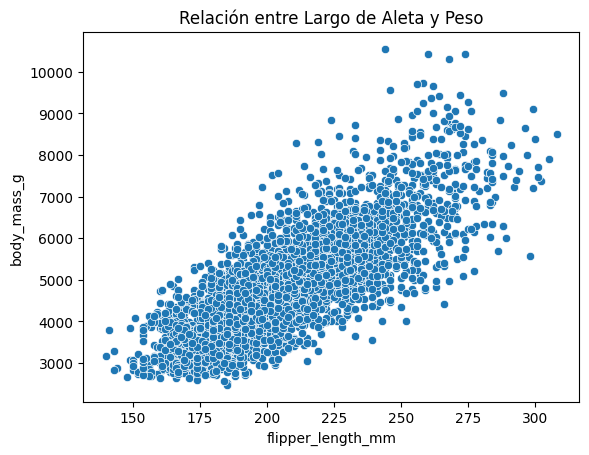

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

penguinsdf = pd.read_csv('archivos_semana_4/Penguins.csv')
penguinsdf = penguinsdf.dropna()

# Miramos la correlación para elegir nuestras variables
# Queremos ver qué variables afectan más al peso (body_mass_g)
plt.figure(figsize=(8, 5))
sns.heatmap(penguinsdf.corr(numeric_only=True), annot=True, cmap="mako")
plt.title("Mapa de Correlación")
plt.show()

# Gráfico de dispersión para confirmar la tendencia
sns.scatterplot(data=penguinsdf, x="flipper_length_mm", y="body_mass_g")
plt.title("Relación entre Largo de Aleta y Peso")
plt.show()

### Paso 3: Modelado de datos

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definimos variables (X es predictora, y es objetivo)
X = penguinsdf[['flipper_length_mm', 'bill_length_mm']] 
y = penguinsdf['body_mass_g']

# 2. División Entrenamiento/Prueba (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Creamos y entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Predicción y Evaluación
y_pred = modelo.predict(X_test)

print(f"Precisión del modelo (R2 Score): {r2_score(y_test, y_pred):.4f}")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.2f}")

Precisión del modelo (R2 Score): 0.6728
Error Cuadrático Medio (MSE): 542435.39


In [7]:
from sklearn.linear_model import Ridge

# 1. Creamos el modelo Ridge con una penalización (alpha)
# Un alpha de 1.0 es un buen punto de partida
modelo_ridge = Ridge(alpha=1.0)

# 2. Entrenamos con los mismos datos X_train (que ya tienen las dos variables)
modelo_ridge.fit(X_train, y_train)

# 3. Predecimos
y_pred_ridge = modelo_ridge.predict(X_test)

# 4. Comparamos los R2
print(f"R2 Lineal Común: {r2_score(y_test, y_pred):.4f}")
print(f"R2 Ridge (Contraída): {r2_score(y_test, y_pred_ridge):.4f}")

R2 Lineal Común: 0.6728
R2 Ridge (Contraída): 0.6728


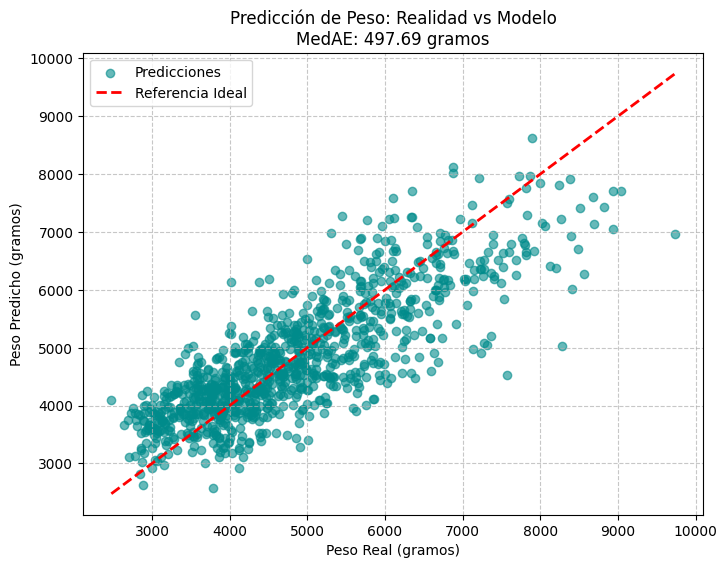

En promedio, el modelo le pifia por 497.69 gramos.


In [8]:
from sklearn.metrics import median_absolute_error
import numpy as np

# 1. Calculamos el MedAE (Métrica robusta a outliers)
medae_ridge = median_absolute_error(y_test, y_pred_ridge)

# 2. Visualización de la "Verdad"
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.6, color='darkcyan', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Referencia Ideal')

plt.title(f'Predicción de Peso: Realidad vs Modelo\nMedAE: {medae_ridge:.2f} gramos')
plt.xlabel('Peso Real (gramos)')
plt.ylabel('Peso Predicho (gramos)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"En promedio, el modelo le pifia por {medae_ridge:.2f} gramos.")